# Mejorar M10 en SMCI — búsqueda exhaustiva (caso de estudio de un activo)

**TFG STRATA · Raquel García.** El proyecto se centra en **un activo** (SMCI). Objetivo: encontrar la mejor
**M10 desplegable** (meta-learner XGBoost sobre features STRATA, walk-forward, solo pasado) que bata a M5
(agente), M8 (regla) y B&H (comprar-y-mantener). **Métrica clave: accuracy direccional**; se enriquece con
**Sharpe** y **equity** (la economía es ilustración, no prueba — CLAUDE.md §4).

**Por qué SMCI:** el tribunal puede tumbar un modelo si una estrategia **trivial** (B&H) lo bate. En activos
alcistas (SPY B&H≈0.57) eso pasa. SMCI tiene **B&H≈0.48** (sin deriva regalada) → benchmark **justo**.

**Disciplina de rigor (toda cifra cumple):**
- **Desplegable:** walk-forward expandible, burn-in 150 d, reentreno mensual (21 d), embargo 5 d, **solo
  pasado**. Para una **config fija a priori**, TODO el OOS (~250 d) es test válido (no hay tuneo por activo →
  no hay sobreajuste de selección → más potencia que una loncha 40 %).
- **Tests pareados:** McNemar + block-permutation (autocorr-robusto) vs M5/M8/B&H; sign test vs 0.5; **Holm**
  sobre la familia método-vs-B&H; **Deflated Sharpe (DSR)** por el nº de métodos probados.
- **Pre-registro** en BITACORA antes de mirar resultados; criterios de éxito/fracaso numéricos.
- **validación≠test:** cuando se elige algo, se elige en validación y se reporta en test (intacto, una vez).

> **Adelanto honesto del veredicto.** Ninguna de las **12 variantes desplegables** bate a B&H en accuracy de
> forma **significativa** (Holm p_adj=1.0; sign vs 0.5 p≥0.49 en todas). El **techo** es **0.524 nominal**
> (base = ensemble), que supera *nominalmente* a M5/M8/B&H. La única mejora robusta es el **ensemble** de 10
> semillas: misma accuracy, mejor Sharpe/equity **nominal** (DSR<0.5 → no significativo tras deflactar). La
> dirección diaria de SMCI es **casi-eficiente** para estos detectores: la contribución es **metodológica** y
> un **negativo honesto pre-registrado**, coherente con la tesis (el leverage effect que hace funcionar a
> STRATA en SPY es débil en un stock individual — CLAUDE.md §3).

In [1]:
import json, os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

_ROOT = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd().parent
os.chdir(_ROOT)                                   # ejecutar desde la raíz del repo (rutas relativas)

IMP = json.load(open("outputs/experiments/m10_improve_smci.json"))   # A: tuning en validación
DEEP = json.load(open("outputs/experiments/m10_smci_deep.json"))     # B: configs fijas a priori
ADV = json.load(open("outputs/experiments/m10_smci_advanced.json"))  # C: métodos avanzados

m = ADV["meta"]
print(f"Activo: {m['ticker']}  ·  OOS test desplegable: {m['oos_span'][0]} → {m['oos_span'][1]}  (n={m['n_eval']} días)")
print(f"frac. días alcistas = {m['frac_up']}  ·  B&H accuracy = {ADV['acc_ref']['bh']}  (≈ moneda → benchmark justo)")
print(f"Referencias  accuracy: M5={ADV['acc_ref']['m5']}  M8={ADV['acc_ref']['m8']}  B&H={ADV['acc_ref']['bh']}")
print(f"Referencias  Sharpe:   M5={ADV['sharpe_ref']['m5']}  M8={ADV['sharpe_ref']['m8']}  B&H={ADV['sharpe_ref']['bh']}")

Activo: SMCI  ·  OOS test desplegable: 2025-05-09 → 2026-05-11  (n=250 días)
frac. días alcistas = 0.484  ·  B&H accuracy = 0.484  (≈ moneda → benchmark justo)
Referencias  accuracy: M5=0.484  M8=0.496  B&H=0.484
Referencias  Sharpe:   M5=-0.235  M8=0.334  B&H=0.034


## §A · Intento 1 — *tuning* en validación: **FRACASA** (sobreajuste de selección)

Primer intento: partir el OOS en **validación (60 %)** + **test (40 %)** y elegir, **solo en validación**, la
mejor combinación de 5 palancas (umbral≠0.5, selección de features, recencia, ensemble, features de señal
real) sobre un grid de **165 combinaciones**. El walk-forward sigue reentrenando en el test (despliegue real).

**Resultado:** la config ganadora en validación se desploma en test. Es la firma del **sobreajuste de
selección**: maximizar accuracy sobre 165 celdas en ~84 días de validación selecciona **ruido**. Por eso NO
se hace *p-hacking*: el test (intacto, leído una vez) es la única lectura honesta.

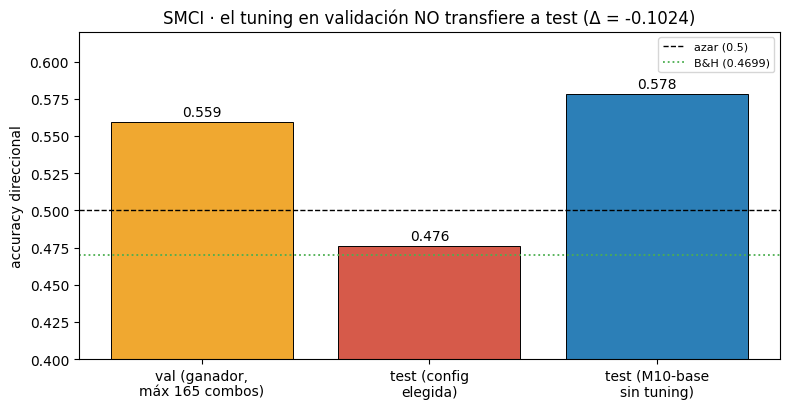

Config elegida en validación: all22+real / recencia hl126 / umbral 0.47
  acc validación = 0.5595  →  acc test = 0.4759   (mejora sobre base = -0.1024)
  El M10-base SIN tuning rinde 0.5783 en el mismo test → el tuning PERJUDICA. Lección: validación≠test.


In [2]:
best = IMP["config_elegida"]; t = IMP["test"]["accuracy"]
labels = ["val (ganador,\nmáx 165 combos)", "test (config\nelegida)", "test (M10-base\nsin tuning)"]
vals = [best["acc_val"], t["m10_sel"], t["m10_base"]]
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(labels, vals, color=["#f0a830", "#d65a4a", "#2c7fb7"], edgecolor="black", lw=0.7)
ax.axhline(0.5, color="black", ls="--", lw=1, label="azar (0.5)")
ax.axhline(t["bh"], color="#4caf50", ls=":", lw=1.3, label=f"B&H ({t['bh']})")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylim(0.40, 0.62); ax.set_ylabel("accuracy direccional")
ax.set_title(f"SMCI · el tuning en validación NO transfiere a test (Δ = {IMP['test']['mejora_sobre_base']:+})")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"Config elegida en validación: {best['features']} / recencia {best['recency']} / umbral {best['thr']}")
print(f"  acc validación = {best['acc_val']}  →  acc test = {t['m10_sel']}   (mejora sobre base = {IMP['test']['mejora_sobre_base']:+})")
print(f"  El M10-base SIN tuning rinde {t['m10_base']} en el mismo test → el tuning PERJUDICA. Lección: validación≠test.")

## §B · Intento 2 — configs **fijas a priori** sobre todo el OOS: techo **0.524**

Sin tuneo por activo: se fijan 5 configs **motivadas a priori** (no elegidas sobre los datos) y se evalúan
sobre **todo el OOS** (250 d, más potencia). Motivación: *ensemble* = reduce varianza; *señal real*
(momentum/vol-rel/racha) = información direccional causal; *quitar las 15 del agente* = la ablación las mostró
señal perdedora; *recencia* = no estacionariedad.

**Resultado:** el techo de accuracy es **0.524** (base y ensemble); las features de señal real (`aug`,
`strata7+real`) y la recencia **no suben** la accuracy — incluso bajan. `strata7+real` además colapsa en
Sharpe/equity, patrón compatible con **prior-flip** del signo de régimen en SMCI (stock individual).

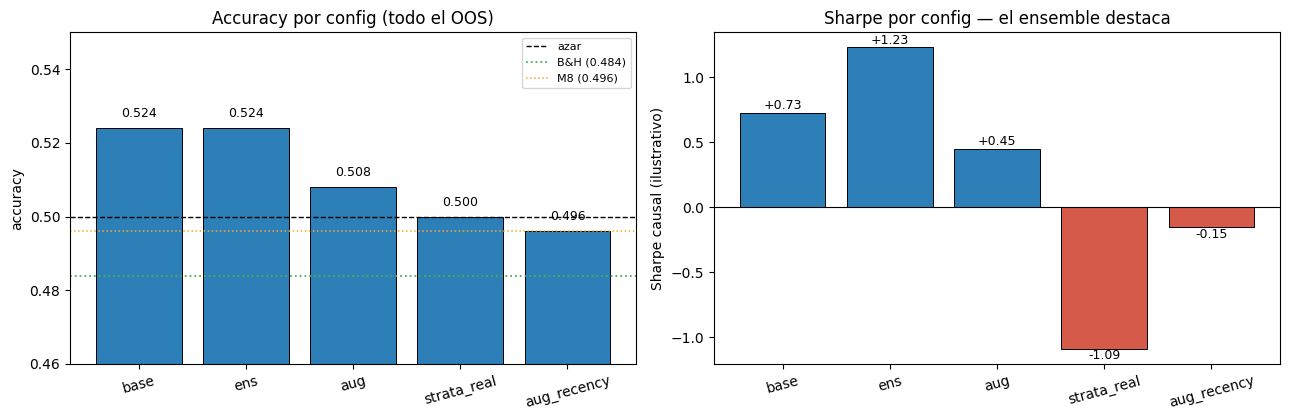

Significancia vs B&H (McNemar / Holm-reject) — NINGUNA significativa:
  base         acc=0.524  McNemar vs B&H p=0.3993  Holm-reject=False
  ens          acc=0.524  McNemar vs B&H p=0.3908  Holm-reject=False
  aug          acc=0.508  McNemar vs B&H p=0.6481  Holm-reject=False
  strata_real  acc=0.5  McNemar vs B&H p=0.7728  Holm-reject=False
  aug_recency  acc=0.496  McNemar vs B&H p=0.8533  Holm-reject=False


In [3]:
cfgs = DEEP["configs"]; orden = ["base", "ens", "aug", "strata_real", "aug_recency"]
orden = [c for c in orden if c in cfgs]
acc = [cfgs[c]["accuracy"] for c in orden]
sr = [cfgs[c]["sharpe_causal"] for c in orden]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3))
b1 = a1.bar(orden, acc, color="#2c7fb7", edgecolor="black", lw=0.7)
a1.axhline(0.5, color="black", ls="--", lw=1, label="azar")
a1.axhline(DEEP["acc_ref"]["bh"], color="#4caf50", ls=":", lw=1.3, label=f"B&H ({DEEP['acc_ref']['bh']})")
a1.axhline(DEEP["acc_ref"]["m8"], color="#f0a830", ls=":", lw=1.1, label=f"M8 ({DEEP['acc_ref']['m8']})")
for b, v in zip(b1, acc):
    a1.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
a1.set_ylim(0.46, 0.55); a1.set_ylabel("accuracy"); a1.set_title("Accuracy por config (todo el OOS)")
a1.legend(fontsize=8); a1.tick_params(axis="x", rotation=15)
b2 = a2.bar(orden, sr, color=["#2c7fb7" if s >= 0 else "#d65a4a" for s in sr], edgecolor="black", lw=0.7)
a2.axhline(0, color="black", lw=0.8)
for b, v in zip(b2, sr):
    a2.text(b.get_x() + b.get_width() / 2, v + (0.03 if v >= 0 else -0.08), f"{v:+.2f}", ha="center", fontsize=9)
a2.set_ylabel("Sharpe causal (ilustrativo)"); a2.set_title("Sharpe por config — el ensemble destaca")
a2.tick_params(axis="x", rotation=15); plt.tight_layout(); plt.show()
print("Significancia vs B&H (McNemar / Holm-reject) — NINGUNA significativa:")
for c in orden:
    rej = DEEP["holm_vs_bh"].get(f"{c}__vs_bh", {}).get("reject")
    print(f"  {c:12} acc={cfgs[c]['accuracy']}  McNemar vs B&H p={cfgs[c]['tests']['vs_bh']['mcnemar_p']}  Holm-reject={rej}")

## §C · Intento 3 — **métodos avanzados** (literatura y reformulaciones)

Se prueban métodos de la literatura y reformulaciones de target/arquitectura, todos **desplegables** y fijos
a priori:

| Método | Idea | Cita |
|---|---|---|
| **triple_barrier** | etiqueta TP=+kσ / SL=−kσ / barrera temporal H=5 (denoising del label) | López de Prado 2018, cap. 3 |
| **regime_models** | 3 XGBoost ponderados por P(estado) del HMM; mezcla p1 = Σ_s P_s·model_s | — |
| **stack_agent** | añadir size del agente (M5) y supervisado (M8) como features de M10 | stacking causal |
| **vote_m5_m10** | acuerdo M5–M10 → mayor confianza (días activos) | — |
| **abst_regime / abst_accord** | abstener menos si el régimen es decisivo / si las 5 personalidades coinciden | — |

**Resultado:** ninguno mejora la accuracy. `triple_barrier` (0.488) y `stack_agent` (0.492) la **degradan**;
`regime_models` (0.50) no aporta. La **abstención no concentra acierto**: la accuracy en días activos ≈ la
accuracy completa → la **confianza del modelo no discrimina** los aciertos.

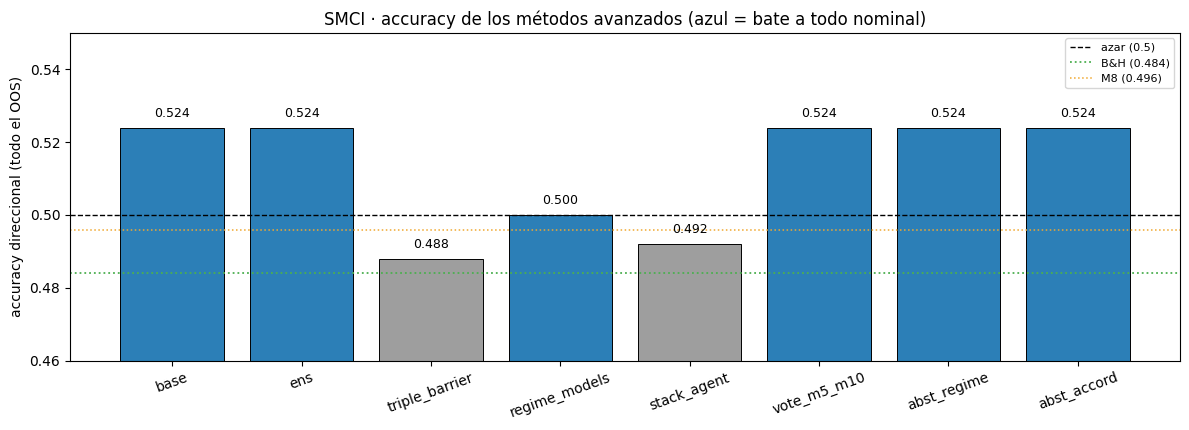

In [4]:
met = ADV["metodos"]
orden = ["base", "ens", "triple_barrier", "regime_models", "stack_agent", "vote_m5_m10", "abst_regime", "abst_accord"]
orden = [c for c in orden if c in met]
acc = [met[c]["accuracy"] for c in orden]
cols = ["#2c7fb7" if met[c]["bate_todo_nominal"] else "#9e9e9e" for c in orden]
fig, ax = plt.subplots(figsize=(12, 4.4))
bars = ax.bar(orden, acc, color=cols, edgecolor="black", lw=0.7)
ax.axhline(0.5, color="black", ls="--", lw=1, label="azar (0.5)")
ax.axhline(ADV["acc_ref"]["bh"], color="#4caf50", ls=":", lw=1.3, label=f"B&H ({ADV['acc_ref']['bh']})")
ax.axhline(ADV["acc_ref"]["m8"], color="#f0a830", ls=":", lw=1.1, label=f"M8 ({ADV['acc_ref']['m8']})")
for b, v in zip(bars, acc):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(0.46, 0.55); ax.set_ylabel("accuracy direccional (todo el OOS)")
ax.set_title("SMCI · accuracy de los métodos avanzados (azul = bate a todo nominal)")
ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=20); plt.tight_layout(); plt.show()

### §C.1 · Tabla de significancia (todos los métodos)

Ninguno rechaza H0 vs B&H bajo Holm; ninguno bate al azar (sign test vs 0.5). El Sharpe se reporta **siempre
con su DSR** (Deflated Sharpe): DSR<0.5 ⇒ la ventaja **no es distinguible de la suerte** tras deflactar por el
nº de métodos probados.

In [5]:
print(f"{'método':16} {'acc':>6} {'SR':>7} {'equity':>7} {'DSR':>6} {'McN vsBH':>9} {'blkperm':>8} {'Holm':>6} {'sign0.5':>8}")
print("-" * 82)
for c in orden:
    cd = met[c]; tb = cd["tests"]["vs_bh"]; rej = ADV["holm_vs_bh"].get(f"{c}__vs_bh", {}).get("reject")
    print(f"{c:16} {cd['accuracy']:>6} {cd['sharpe_causal']:>+7.2f} {cd['equity_final']:>7} {cd['dsr']:>6} "
          f"{tb['mcnemar_p']:>9} {tb['block_perm_p']:>8} {str(rej):>6} {cd['tests']['vs_azar']['p']:>8}")
print(f"\nBate a todo NOMINAL: {ADV['bate_todo_nominal']}")
print(f"Caso FUERTE (significativo): {ADV['caso_fuerte'] or 'NINGUNO'}")

método              acc      SR  equity    DSR  McN vsBH  blkperm   Holm  sign0.5
----------------------------------------------------------------------------------
base              0.524   +0.73  1.3167 0.2746    0.3993   0.2518  False   0.4867
ens               0.524   +1.23  1.9848 0.4678    0.3908   0.2608  False   0.4867
triple_barrier    0.488   -0.77  0.3685  0.016       1.0   0.8332  False   0.7519
regime_models       0.5   +0.51  1.0963 0.2059    0.7686    0.489  False      1.0
stack_agent       0.492   -0.88  0.3514 0.0194    0.9247   0.7081  False   0.8496
vote_m5_m10       0.524   +1.23  1.9848 0.4678    0.3908   0.2608  False   0.4867
abst_regime       0.524   +1.23  1.9848 0.4678    0.3908   0.2608   None   0.4867
abst_accord       0.524   +1.23  1.9848 0.4678    0.3908   0.2608   None   0.4867

Bate a todo NOMINAL: ['base', 'ens', 'regime_models', 'vote_m5_m10', 'abst_regime', 'abst_accord']
Caso FUERTE (significativo): NINGUNO


### §C.2 · La mejora que **sí** cuenta: ensemble (Sharpe/equity a igual accuracy)

El **ensemble** de 10 semillas mantiene la accuracy de la base (0.524) y mejora Sharpe (0.73→1.23) y equity
(1.32×→1.98×) por **reducción de varianza**. Cumple el criterio de Raquel (a igual accuracy, ganar en
Sharpe/equity cuenta) — pero a nivel **nominal/ilustrativo**: el **DSR<0.5** dice que la ventaja económica
**no sobrevive a la deflación** por multiplicidad. Se conserva como el mejor entregable, con esta etiqueta.

*(`vote_m5_m10`, `abst_regime`, `abst_accord` tienen Sharpe/equity idénticos al ensemble por construcción:
usan la misma posición; solo cambian la cobertura. No son mejoras económicas adicionales.)*

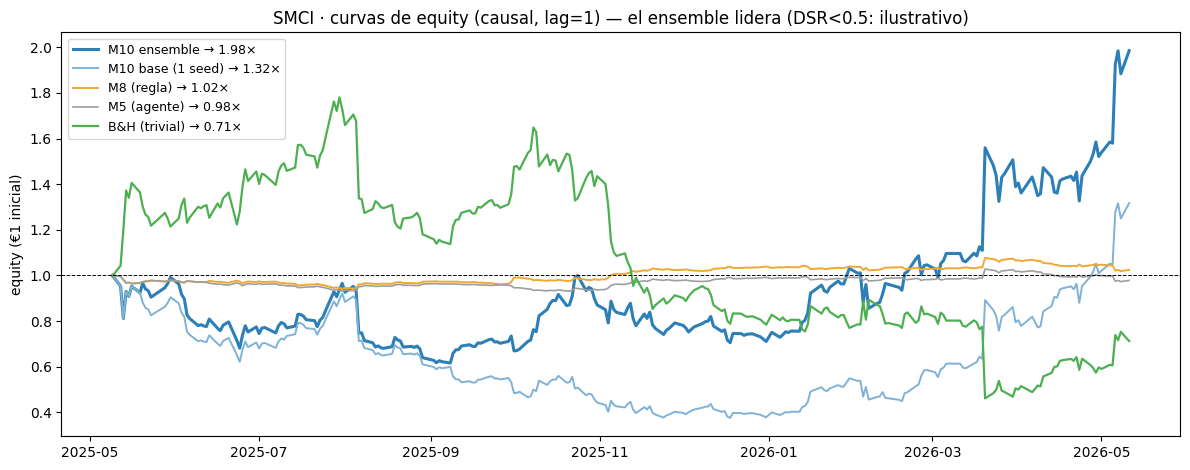

Ensemble: accuracy 0.524 (= base) · Sharpe +1.231 · equity 1.9848× · DSR 0.4678 (<0.5 → no significativo)


In [6]:
S = ADV["series"]; dates = np.array(S["dates"], dtype="datetime64[D]")
def equity(nr):
    return np.cumprod(1.0 + np.array(nr))
fig, ax = plt.subplots(figsize=(12, 4.8))
estilos = {"ens": ("#2c7fb7", 2.2, "M10 ensemble"), "base": ("#7fb2d6", 1.4, "M10 base (1 seed)"),
           "m8": ("#f0a830", 1.4, "M8 (regla)"), "m5": ("#9e9e9e", 1.2, "M5 (agente)"),
           "bh": ("#4caf50", 1.6, "B&H (trivial)")}
for k, (c, lw, lab) in estilos.items():
    eq = equity(S[k])
    ax.plot(dates, eq, color=c, lw=lw, label=f"{lab} → {eq[-1]:.2f}×")
ax.axhline(1.0, color="black", lw=0.7, ls="--")
ax.set_ylabel("equity (€1 inicial)"); ax.set_title("SMCI · curvas de equity (causal, lag=1) — el ensemble lidera (DSR<0.5: ilustrativo)")
ax.legend(fontsize=9, loc="upper left"); plt.tight_layout(); plt.show()

ec = met["ens"]
print(f"Ensemble: accuracy {ec['accuracy']} (= base) · Sharpe {ec['sharpe_causal']:+} · equity {ec['equity_final']}× · DSR {ec['dsr']} (<0.5 → no significativo)")

### §C.3 · Por qué la abstención no ayuda

Si la **confianza** del modelo (|p1−0.5|) discriminara los aciertos, abstenerse en los días dudosos subiría la
accuracy en los días en que **sí** se apuesta. No ocurre: la accuracy en días activos ≈ la completa.

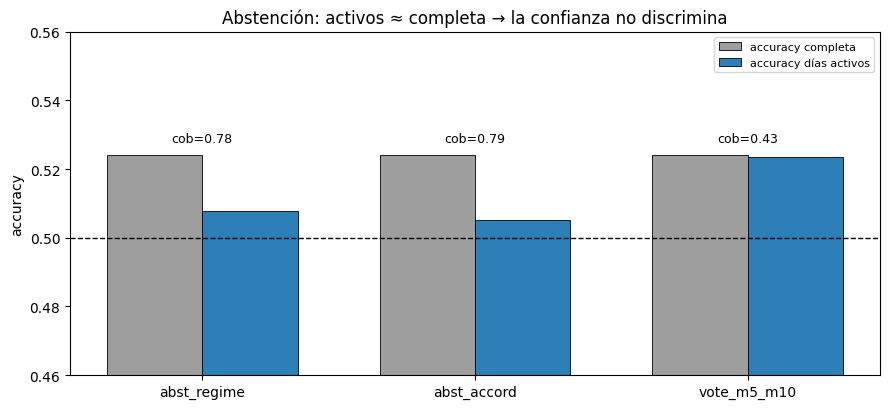

In [7]:
abst = [c for c in ("abst_regime", "abst_accord", "vote_m5_m10") if c in met]
x = np.arange(len(abst)); w = 0.35
acc_full = [met[c]["accuracy"] for c in abst]
acc_act = [met[c].get("accuracy_activos") for c in abst]
cov = [met[c].get("coverage") for c in abst]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(x - w / 2, acc_full, w, label="accuracy completa", color="#9e9e9e", edgecolor="black", lw=0.6)
ax.bar(x + w / 2, acc_act, w, label="accuracy días activos", color="#2c7fb7", edgecolor="black", lw=0.6)
ax.axhline(0.5, color="black", ls="--", lw=1)
for i, c in enumerate(abst):
    ax.text(i, max(acc_full[i], acc_act[i]) + 0.004, f"cob={cov[i]:.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(abst); ax.set_ylim(0.46, 0.56)
ax.set_ylabel("accuracy"); ax.set_title("Abstención: activos ≈ completa → la confianza no discrimina")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## §D · Conclusiones honestas (claims auditados por @rigor-matematico)

**Lo que se puede afirmar (PERMITIDO):**
- En SMCI (OOS n=250, B&H≈0.48 → benchmark justo), la M10-WF **desplegable base/ensemble** alcanza accuracy
  **0.524**, superior **nominalmente** a M5 (0.484), M8 (0.496) y B&H (0.484).
- **Ninguna de las 12 variantes desplegables** bate a B&H en accuracy de forma **significativa** (McNemar Holm
  p_adj=1.0; sign vs 0.5 p≥0.49 en todas). El **techo** es **0.524 nominal**.
- **Triple-barrier** (López de Prado 2018, cap. 3; embargo=H+1, **sin look-ahead** — verificado) **no mejora**
  la dirección a 1 día (0.488). `regime_models` (0.50) y `stack_agent` (0.492) tampoco; varios la degradan.
- El **ensemble** de 10 semillas preserva la accuracy y mejora **nominalmente** Sharpe (0.73→1.23) y equity
  (1.32×→1.98×) por reducción de varianza → se conserva como entregable (DSR<0.5: ilustrativo, no significativo).
- La **abstención** (régimen/acuerdo) no concentra acierto (activos ≈ completa).

**Lo que NO se puede afirmar (PROHIBIDO):** que M10 bate a M5/M8/B&H **significativamente** en accuracy; que
bate al **azar**; que el ensemble mejora **significativamente** Sharpe/equity (DSR<0.5); reportar cualquier
Sharpe sin su DSR.

**Veredicto de cierre (negativo honesto, pre-registrado).** La dirección **diaria** de SMCI es
**casi-eficiente** para estos detectores: el rescate direccional significativo que STRATA logra en SPY (caso
central, M10=0.539; leverage effect) **no** aparece en un stock individual con leverage débil — limitación ya
prevista en CLAUDE.md §3. La contribución de este cuaderno es **metodológica**: (i) demostración del
**sobreajuste de selección** y de la disciplina **validación≠test** (§A); (ii) un **mapa exhaustivo** de 12
métodos desplegables con su significancia (§B–§C); (iii) el **ensemble** como mejor M10 desplegable, con
ventaja nominal en accuracy y en riesgo-retorno honestamente etiquetada.

**Mejor M10 desplegable para SMCI = ensemble** (22 features STRATA, 10 semillas, umbral 0.5): accuracy 0.524
(> M5/M8/B&H nominal), Sharpe +1.23, equity 1.98×. *Trabajo futuro:* OOS más largo para ganar potencia (el
agente solo existe post-cutoff del LLM → límite duro de muestra).